In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path

In [13]:
# --- 1. CONFIGURACIÓN DE RUTAS (Compatible Windows/Linux) ---
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "raw" / "waste_classification" / "images"
MODELS_DIR = BASE_DIR / "models"
MODEL_PATH = MODELS_DIR / "modelo_residuos_rpi.keras"
FIGURES_DIR = BASE_DIR / "reports" / "figures"

In [14]:
# Verificamos que existan
if not DATA_DIR.exists():
    raise FileNotFoundError(f"No se encontraron los datos en: {DATA_DIR}")
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"No se encontró el modelo en: {MODEL_PATH}. ¡Ejecuta el entrenamiento primero!")

print(f"Rutas verificadas.")
print(f"Cargando modelo desde: {MODEL_PATH}")

Rutas verificadas.
Cargando modelo desde: ..\models\modelo_residuos_rpi.keras


In [15]:
# --- 2. CARGA DEL MODELO ---
model = load_model(MODEL_PATH)
print("Modelo cargado exitosamente.")

Modelo cargado exitosamente.


In [16]:
# --- 3. PREPARACIÓN DE DATOS (Solo Validación) ---
# Usamos las mismas dimensiones que en el entrenamiento
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 # Podemos usar un batch más grande para inferencia

# Solo necesitamos re-escalar, no hacemos Data Augmentation para evaluar
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

print("Generando set de validación...")
val_gen = datagen.flow_from_directory(
    str(DATA_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False # ¡IMPORTANTE! No mezclar para que coincidan las etiquetas con la predicción
)

class_labels = list(val_gen.class_indices.keys())
print(f"Clases detectadas: {len(class_labels)}")

Generando set de validación...
Found 3000 images belonging to 30 classes.
Clases detectadas: 30


In [17]:
# --- 4. GENERACIÓN DE PREDICCIONES ---
print("\nRealizando predicciones sobre el set de validación (esto puede tardar unos segundos)...")
predictions = model.predict(val_gen, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_gen.classes


Realizando predicciones sobre el set de validación (esto puede tardar unos segundos)...
94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 265ms/step



Generando Matriz de Confusión...
Gráfica guardada exitosamente en: C:\Users\river\Documents\GitHub\EntrenamientoIA\reports\figures\matriz_confusion_final.png


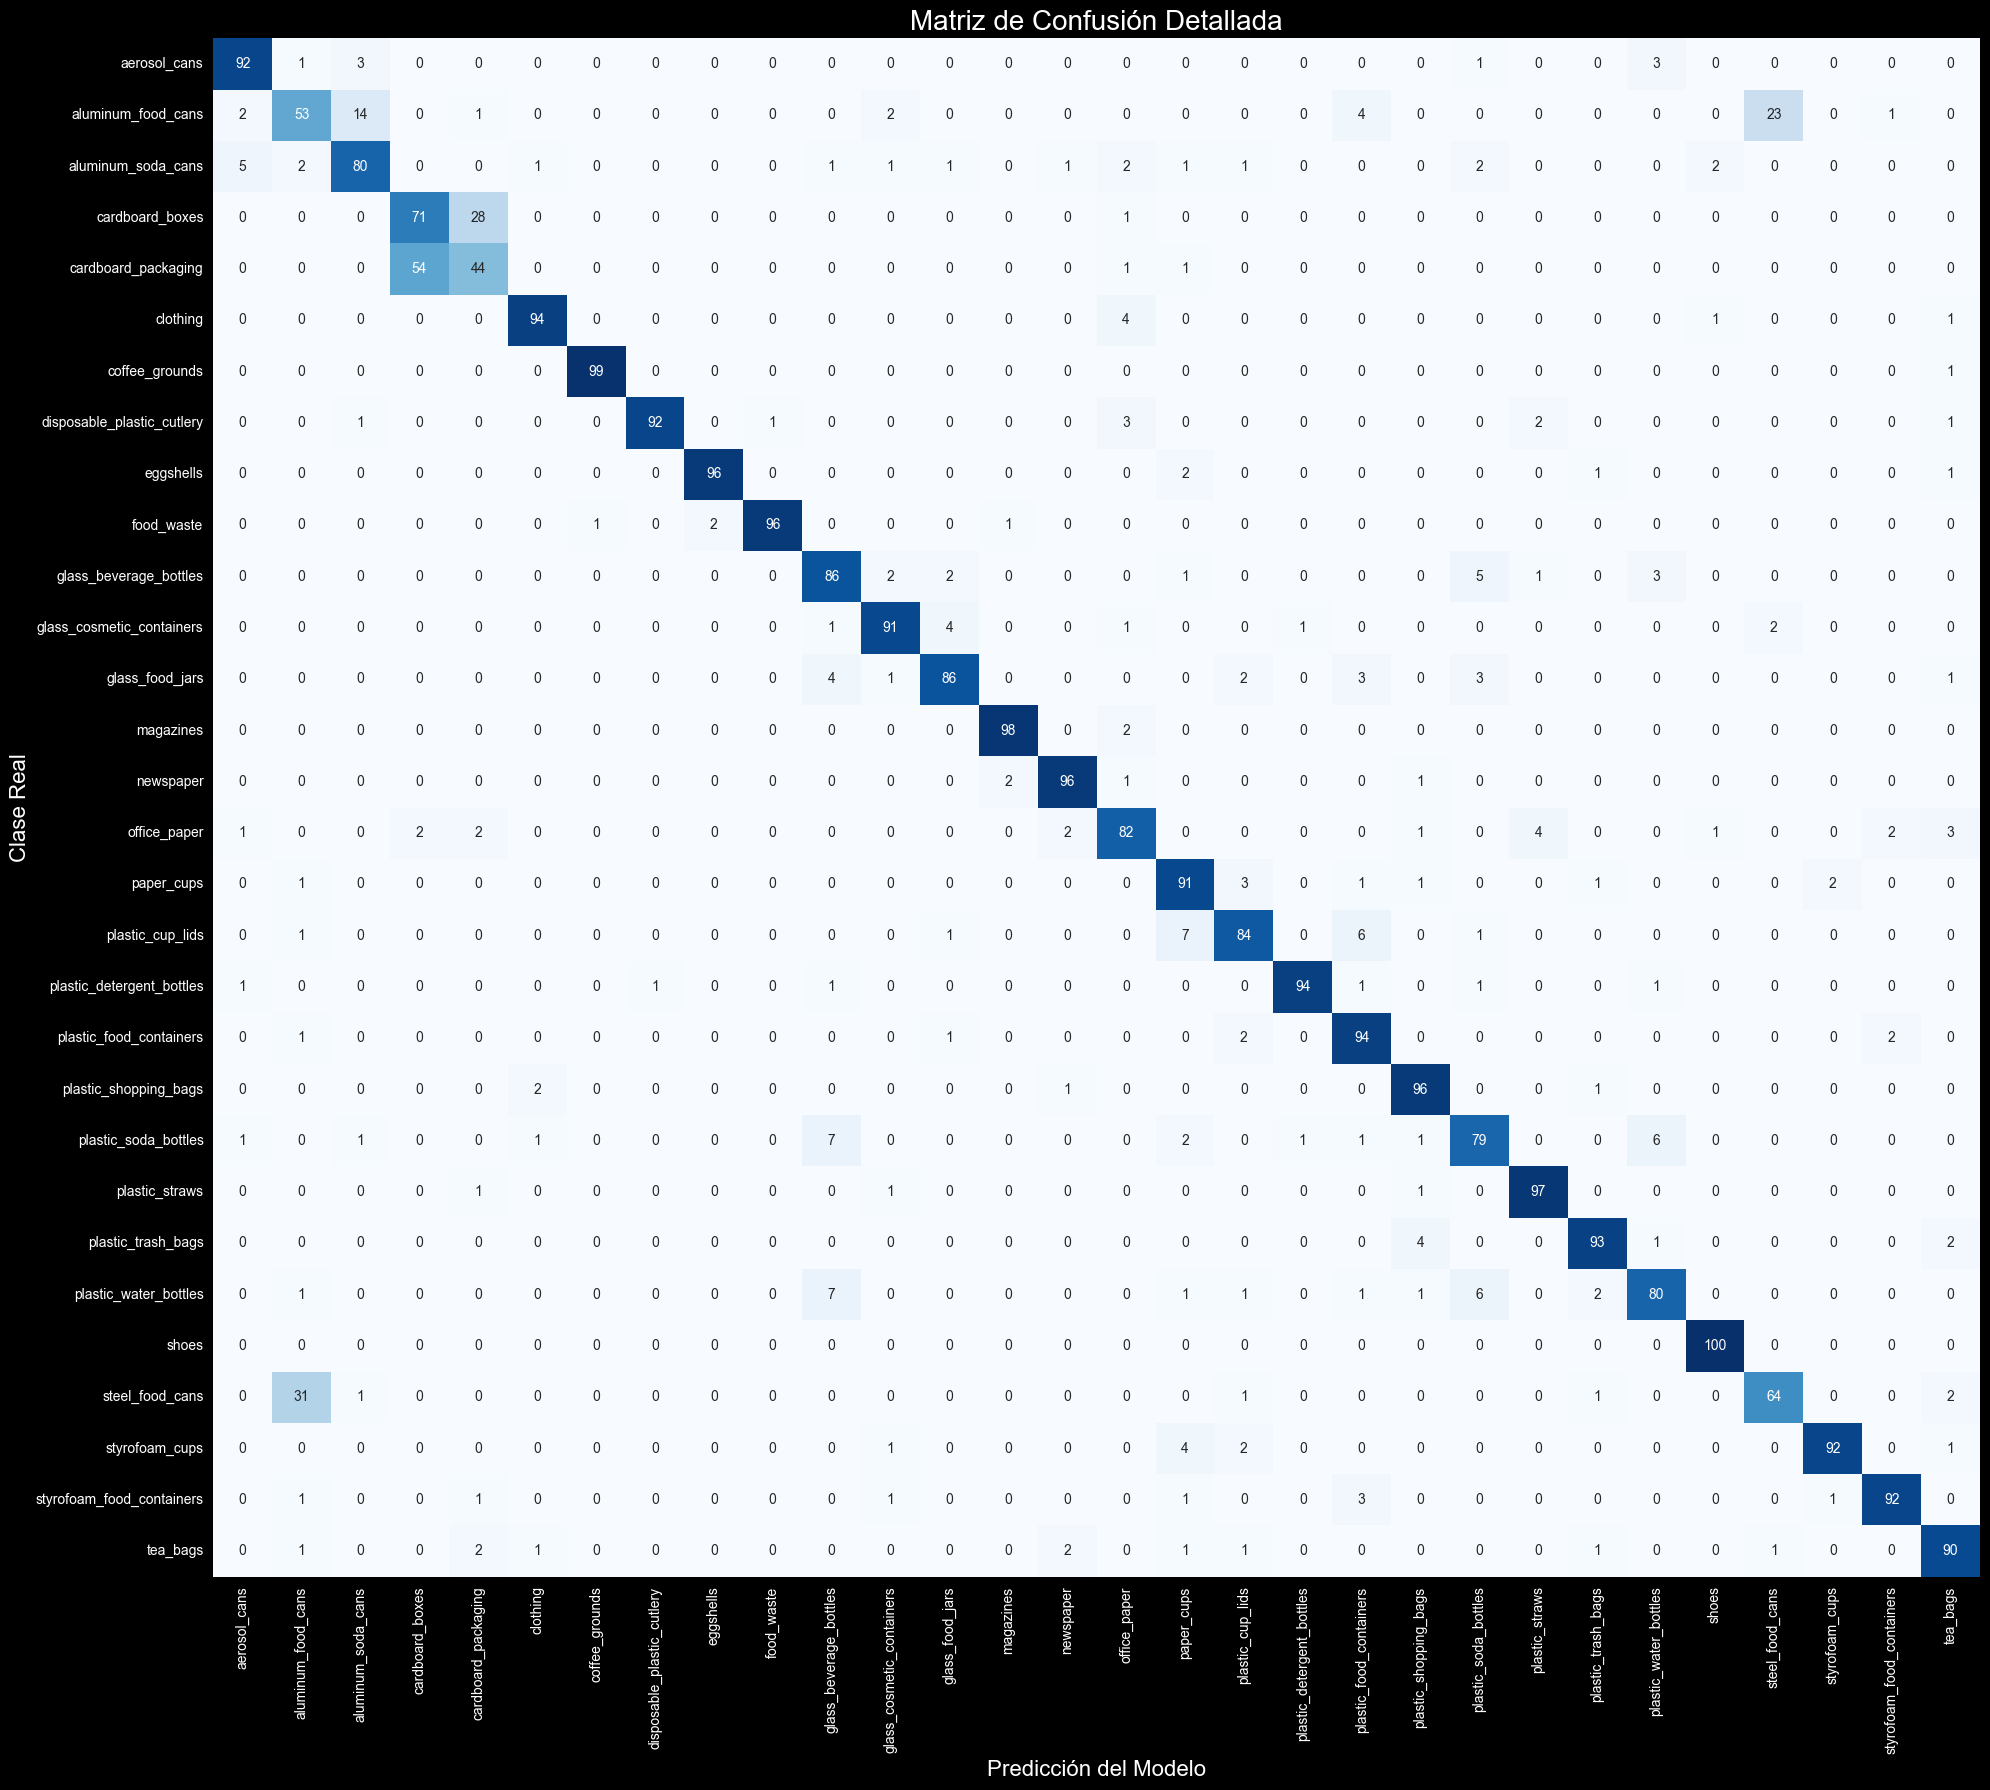

In [18]:
# --- 5. VISUALIZACIÓN: MATRIZ DE CONFUSIÓN ---
print("\nGenerando Matriz de Confusión...")
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('Matriz de Confusión Detallada', fontsize=20)
plt.xlabel('Predicción del Modelo', fontsize=16)
plt.ylabel('Clase Real', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
save_path = FIGURES_DIR / "matriz_confusion_final.png"
plt.savefig(
    save_path,
    dpi=300,                # Alta resolución (estándar para impresión/papers)
    bbox_inches='tight',    # ¡CRUCIAL! Evita que se corten los nombres largos de las clases
    facecolor='white'       # Fondo blanco forzado (útil si usas temas oscuros en VS Code/Colab)
)
print(f"Gráfica guardada exitosamente en: {save_path.resolve()}")
plt.show()

In [19]:
# --- 6. REPORTE DE MÉTRICAS ---
print("\nReporte de Clasificación por Clase:\n")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))


Reporte de Clasificación por Clase:

                            precision    recall  f1-score   support

              aerosol_cans       0.90      0.92      0.91       100
        aluminum_food_cans       0.57      0.53      0.55       100
        aluminum_soda_cans       0.80      0.80      0.80       100
           cardboard_boxes       0.56      0.71      0.63       100
       cardboard_packaging       0.56      0.44      0.49       100
                  clothing       0.95      0.94      0.94       100
            coffee_grounds       0.99      0.99      0.99       100
disposable_plastic_cutlery       0.99      0.92      0.95       100
                 eggshells       0.98      0.96      0.97       100
                food_waste       0.99      0.96      0.97       100
    glass_beverage_bottles       0.80      0.86      0.83       100
 glass_cosmetic_containers       0.91      0.91      0.91       100
           glass_food_jars       0.91      0.86      0.88       100
         

In [20]:
# --- 7. VER ERRORES ESPECÍFICOS ---
# Muestra índices donde el modelo falló para revisión manual
errors = np.where(predicted_classes != true_classes)[0]
print(f"\nTotal de errores encontrados: {len(errors)} de {len(true_classes)} imágenes.")
print(f"   Precisión Global (Accuracy): {1 - len(errors)/len(true_classes):.2%}")


Total de errores encontrados: 398 de 3000 imágenes.
   Precisión Global (Accuracy): 86.73%
